# M3: obična RNN

Ova sveska trenira i ocenjuje M3 RNN nad sekvencama prethodno odigranih mečeva. M3 je najjednostavnija od tri rekurentne mreže i služi kao ablacija — pokazuje koliko kapije (LSTM, GRU) zaista donose preko obične rekurentne ćelije.

Svaka rekurentna mreža ima svoju svesku, da bi se moglo raditi paralelno. Sve tri dele istu arhitekturu (`models.MatchPredictor`) i istu petlju treniranja (`train.train_model`), ali je svaka podešena nezavisno — razlikuje se parametar `cell`, a hiperparametri se biraju posebno po mreži.

Izbor hiperparametara ide u dva koraka, a izabrana postavka se trenira sa pet seedova iz `config.SEEDS`, jer su početne težine i redosled paketića slučajni pa jedan seed ume prividno da izdvoji jednu mrežu. Prijavljena metrika je prosek po seedovima. Potpuno izvršavanje istrenira oko osamdeset mreža i traje desetak do petnaest minuta.

Skup podataka se može preuzeti sa [ove](https://www.kaggle.com/datasets/nathanlauga/nba-games) adrese.

## Priprema

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd

import torch
from torch.utils.data import DataLoader

from src.config import (BATCH_SIZE, MODELS_PATH, PROCESSED_DATA_PATH, RANDOM_STATE,
                        RESULTS_FILE, SEEDS)
from src import evaluate, models, plotting, sequences, train

train.set_seed(RANDOM_STATE)

## Učitavanje sekvenci

Iste `sekvence.npz` i iste `train`/`validation` pozicije kao u svesci 02/03 — isti mečevi kao za M0–M2, kako bi poređenje bilo pošteno. Test skup se ovde ne učitava: dodiruje se tačno jednom, na kraju, u svesci 05.

In [2]:
splits = np.load(PROCESSED_DATA_PATH / "sekvence.npz")
home_sequences, away_sequences = splits["home_sequences"], splits["away_sequences"]
context, labels = splits["context"], splits["labels"]
train_idx, validation_idx = splits["train"], splits["validation"]

home_train, away_train = home_sequences[train_idx], away_sequences[train_idx]
context_train, y_train = context[train_idx], labels[train_idx]

home_val, away_val = home_sequences[validation_idx], away_sequences[validation_idx]
context_val, y_val = context[validation_idx], labels[validation_idx]

home_train.shape, context_train.shape

((18092, 10, 8), (18092, 24))

## Dataset i DataLoader

`shuffle=True` meša samo redosled kojim mreža vidi već-fiksirane trening mečeve unutar jedne epohe — ne dira podelu na skupove, koja je hronološka i fiksirana još u svesci 02. Validacija se ne meša, jer se na njoj ne trenira.

In [3]:
dataset_train = sequences.MatchSequenceDataset(home_train, away_train, context_train, y_train)
dataset_val = sequences.MatchSequenceDataset(home_val, away_val, context_val, y_val)

loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)

len(dataset_train), len(dataset_val)

(18092, 2624)

## Izbor hiperparametara

Hiperparametri se biraju pre treniranja, jer sve što sledi zavisi od njih. Pretraga ide u dva koraka.

Prvo gruba pretraga po celoj mreži vrednosti iz `config.py` (`HIDDEN_SIZE_GRID`, `DROPOUT_GRID`, `LEARNING_RATE_GRID`), sa jednim seedom po kombinaciji. Zatim se prvih `N_FINALISTS` kandidata trenira ponovo, sa svih pet seedova, i pobednik se bira po proseku.

Drugi korak postoji zato što jedno merenje po kombinaciji nije dovoljno da ih razdvoji — razlike u vrhu tabele su reda veličine rasipanja po seedovima. Mreža vrednosti i broj finalista stoje u `config.py`, isti za sve tri rekurentne mreže.

**Prvi korak — gruba pretraga.** Jedan seed po kombinaciji, poredak po `roc_auc` na validaciji.

In [4]:
rezultati_pretrage = train.search_hyperparameters(
    loader_train, loader_val,
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="rnn",
)

rezultati_pretrage.head(5).round(4)

,hidden_size,dropout,learning_rate,tacnost,roc_auc,log_loss,brier
0,64,0.15,0.003,0.6585,0.6974,0.6170,0.2140
1,128,0.30,0.001,0.6604,0.6973,0.6174,0.2143
2,128,0.15,0.001,0.6559,0.6972,0.6173,0.2142
3,128,0.00,0.003,0.6540,0.6971,0.6173,0.2141
4,64,0.30,0.003,0.6601,0.6969,0.6173,0.2142


**Drugi korak.** Svaki finalista se trenira pet puta, pa se poredi prosek. Kolona `rasipanje` pokazuje koliko se ishod menja od pokretanja do pokretanja.

In [5]:
finalisti = train.refine_hyperparameters(
    rezultati_pretrage, dataset_train, dataset_val,
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="rnn",
)

finalisti.round(4)

,hidden_size,dropout,learning_rate,tacnost,rasipanje,roc_auc,roc_auc_rasipanje
0,64,0.15,0.003,0.6579,0.0020,0.6968,0.0007
1,64,0.30,0.003,0.6585,0.0025,0.6967,0.0010
2,128,0.30,0.001,0.6577,0.0014,0.6955,0.0008
3,128,0.00,0.003,0.6563,0.0014,0.6954,0.0015
4,128,0.15,0.001,0.6581,0.0020,0.6953,0.0005


In [6]:
najbolji = finalisti.iloc[0]

print(f"hidden_size   {int(najbolji['hidden_size'])}")
print(f"dropout       {najbolji['dropout']}")
print(f"learning_rate {najbolji['learning_rate']}")
print(f"roc_auc       {najbolji['roc_auc']:.4f} +- {najbolji['roc_auc_rasipanje']:.4f}")
print(f"tacnost       {najbolji['tacnost']:.4f} +- {najbolji['rasipanje']:.4f}")

hidden_size   64
dropout       0.15
learning_rate 0.003
roc_auc       0.6968 +- 0.0007
tacnost       0.6579 +- 0.0020


Dvostepena pretraga potvrđuje pobednika grube pretrage: `hidden_size=64`, `dropout=0.15`, `learning_rate=0.003`. Izbor pritom nije oštar. Svih pet finalista staje u raspon od 0.0015 ROC-AUC (0.6953–0.6968), a pojedinačno rasipanje po seedovima ide do 0.0010 ROC-AUC — širina vrha tabele je reda veličine šuma. Prva dva mesta imaju istu `hidden_size` i istu stopu učenja, razlikuju se samo po `dropout`-u (0.15 naspram 0.30) i po 0.0001 ROC-AUC, pa su praktično nerazlučiva.

Izabrana stopa učenja `0.003` je najveća u mreži iz `config.py`. Pošto je pobednik pao na samu granicu, na kraju sveske proveravamo šta leži izvan nje.

## Kreiranje mreže

`cell="rnn"` daje M3 RNN.

`MatchPredictor` obrađuje sekvencu domaćina i sekvencu gosta **istom** ćelijom (deljene težine), uzima poslednje skriveno stanje svake kao naučeni sažetak forme, nalepi ih uz kontekst i propusti kroz jedan linearni sloj do sirovog logita.

In [7]:
train.set_seed(RANDOM_STATE)

model_rnn = models.MatchPredictor(
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="rnn",
    hidden_size=int(najbolji["hidden_size"]),
    dropout=float(najbolji["dropout"]),
)
model_rnn

MatchPredictor(
  (encoder): RNN(8, 64, batch_first=True)
  (dropout): Dropout(p=0.15, inplace=False)
  (output): Linear(in_features=152, out_features=1, bias=True)
)

## Treniranje mreže

Ista postavka se trenira pet puta, po jednom za svaki seed iz `config.SEEDS`, jer su početne težine i redosled paketića slučajni.

Prijavljena metrika je prosek po seedovima. Grafici i matrica konfuzije se crtaju za jedan model, pa za njih služi prolaz sa seedom `RANDOM_STATE`.

In [8]:
prolazi = train.train_over_seeds(
    dataset_train, dataset_val,
    n_features=home_train.shape[-1],
    n_context=context_train.shape[-1],
    cell="rnn",
    hidden_size=int(najbolji["hidden_size"]),
    dropout=float(najbolji["dropout"]),
    learning_rate=float(najbolji["learning_rate"]),
)

# reprezentativni prolaz - onaj sa seedom iz config.py; sluzi za grafike,
# matricu konfuzije i kalibraciju, koje se crtaju za jedan model
model_rnn = next(p["model"] for p in prolazi if p["seed"] == RANDOM_STATE)
history = next(p["history"] for p in prolazi if p["seed"] == RANDOM_STATE)

pd.DataFrame([{
    "seed": p["seed"],
    "epoha": len(p["history"]["train_loss"]),
    "najbolja": int(np.argmin(p["history"]["valid_loss"])) + 1,
    **p["metrike"],
} for p in prolazi]).round(4)

,seed,epoha,najbolja,tacnost,roc_auc,log_loss,brier
0,7,14,9,0.6551,0.6967,0.6175,0.2142
1,17,9,4,0.6604,0.6964,0.6180,0.2144
2,27,13,8,0.6562,0.6958,0.6185,0.2146
3,37,11,6,0.6597,0.6978,0.6170,0.2140
4,47,17,12,0.6578,0.6972,0.6175,0.2142


## Krive učenja

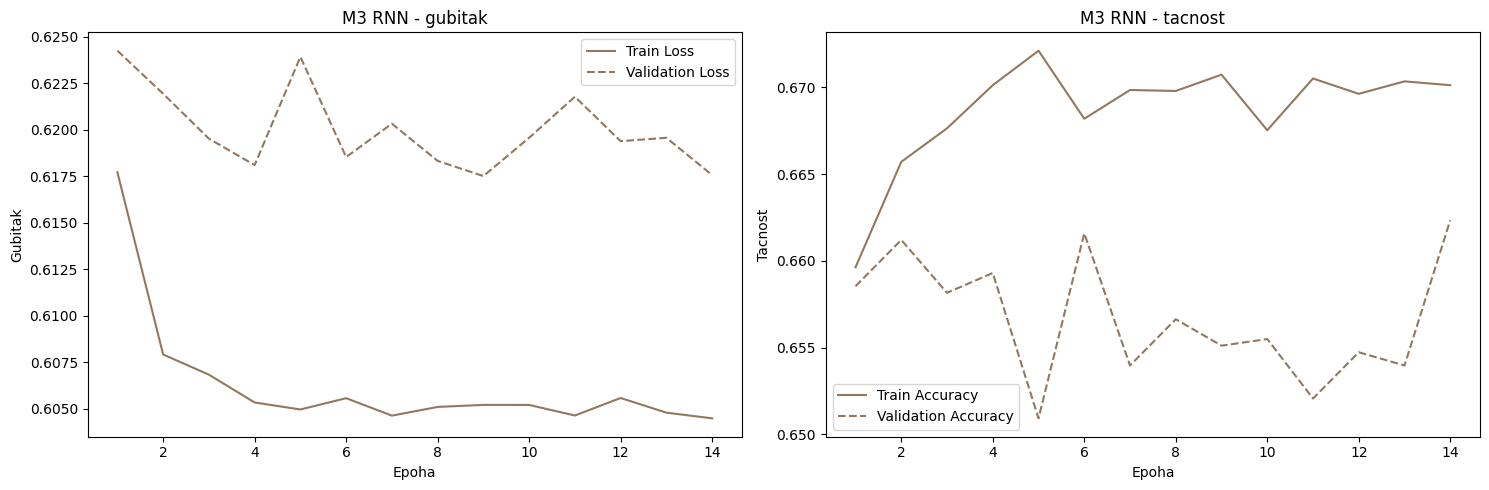

najbolja epoha: 9 od 14
validacioni gubitak: prva epoha 0.6243, najbolja 0.6175, poslednja 0.6176
razmak trening-validacija: 0.007 -> 0.013
validaciona tacnost: od 0.6509 do 0.6623


In [9]:
plotting.plot_learning_curves(history, "M3 RNN")

najbolja = int(np.argmin(history["valid_loss"]))
print(f"najbolja epoha: {najbolja + 1} od {len(history['valid_loss'])}")
print(f"validacioni gubitak: prva epoha {history['valid_loss'][0]:.4f},"
      f" najbolja {history['valid_loss'][najbolja]:.4f},"
      f" poslednja {history['valid_loss'][-1]:.4f}")
print(f"razmak trening-validacija: {history['valid_loss'][0] - history['train_loss'][0]:.3f}"
      f" -> {history['valid_loss'][-1] - history['train_loss'][-1]:.3f}")
print(f"validaciona tacnost: od {min(history['valid_accuracy']):.4f}"
      f" do {max(history['valid_accuracy']):.4f}")

Prikazan je prolaz sa seedom `RANDOM_STATE` (7). Levi grafik pokazuje gubitak: trening opada kroz sve epohe, a validacija dostiže minimum u 9. epohi (0.6175), pa rano zaustavljanje preseca trening u 14. Razmak između krivih raste sa 0.007 na 0.013 — blago preprilagođavanje koje rano zaustavljanje hvata.

Desni grafik pokazuje tačnost bez jasnog trenda: osciluje između 0.6509 i 0.6623, raspon od 1.1 procentnog poena kod jednog istog modela, samo kroz epohe. Po tabeli iznad, najbolja epoha se među seedovima kreće od 4 do 12 — još jedan razlog zašto se prijavljuje prosek po seedovima, a ne jedan prolaz.

## Evaluacija modela

Matrica konfuzije, metrike po klasi i kalibracija na validaciji; zbirne metrike idu u `reports/rezultati.csv` kao prosek po seedovima, a pojedinačni prolazi u `reports/rasipanje-semena.csv`. Test skup se ovde ne dodiruje.

Klase nisu u ravnoteži (oko 59% naspram 41%), pa tačnost sažima dva vrlo različita ponašanja. Preciznost, odziv i F1 po klasi ih razdvajaju.

In [10]:
loader_train_eval = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=False)

for skup, loader in [("trening", loader_train_eval), ("validacija", loader_val)]:
    po_seedu = []

    for prolaz in prolazi:
        y_proba, y_true = train.predict_proba(prolaz["model"], loader)
        metrike = evaluate.compute_metrics(y_true, y_proba)
        evaluate.append_seed_results("M3 RNN", skup, prolaz["seed"], metrike)
        po_seedu.append(metrike)

    prosek = {kljuc: float(np.mean([m[kljuc] for m in po_seedu])) for kljuc in po_seedu[0]}
    evaluate.append_results("M3 RNN", skup, prosek)

# test redovi se ovde ne prikazuju: ova sveska ih ne racuna i ne sme da
# ih otkrije, jer se test otvara tek u svesci 05
pd.read_csv(RESULTS_FILE).query("skup != 'test'").reset_index(drop=True)

,model,skup,tacnost,roc_auc,log_loss,brier
0,M5 GRU,trening,0.673889,0.715839,0.601378,0.207469
1,M5 GRU,validacija,0.655107,0.698265,0.617979,0.214296
2,M0 domacin,trening,0.599547,0.500000,0.673195,0.240090
3,M0 domacin,validacija,0.588796,0.500000,0.677534,0.242231
4,M1 log. reg.,trening,0.672452,0.714898,0.601936,0.207725
5,M1 log. reg.,validacija,0.656250,0.695323,0.620364,0.215363
6,M2 XGBoost,trening,0.683396,0.731799,0.590812,0.202857
7,M2 XGBoost,validacija,0.657012,0.699032,0.616667,0.213756
8,M4 LSTM,trening,0.672784,0.716168,0.601774,0.207598
9,M4 LSTM,validacija,0.656555,0.696930,0.617705,0.214307


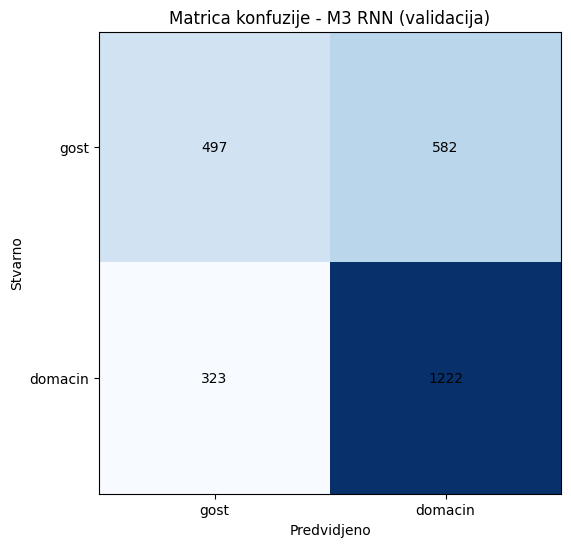

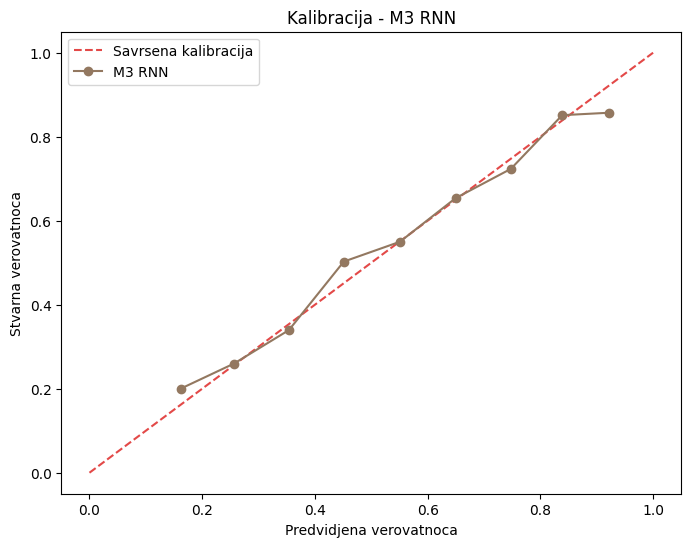

In [11]:
y_proba_val, y_true_val = train.predict_proba(model_rnn, loader_val)
y_pred_val = (y_proba_val >= 0.5).astype(int)

evaluate.plot_confusion_matrix(y_true_val, y_pred_val, "Matrica konfuzije - M3 RNN (validacija)")
evaluate.plot_calibration_curve(y_true_val, y_proba_val, "M3 RNN")

In [12]:
print(evaluate.compute_class_report(y_true_val, y_pred_val))

              precision    recall  f1-score   support

        gost      0.606     0.461     0.523      1079
     domacin      0.677     0.791     0.730      1545

    accuracy                          0.655      2624
   macro avg      0.642     0.626     0.627      2624
weighted avg      0.648     0.655     0.645      2624



Model mnogo bolje prepoznaje domaćine nego goste: odziv je 0.791 naspram 0.461. Pobedu domaćina najavljuje na oko 69% mečeva, iako domaćin pobeđuje u 58.9% — prag 0.5 nad neuravnoteženim klasama vuče predviđanja ka većoj klasi, pa je makro F1 (0.627) niži od tačnosti (0.655). Isti obrazac se vidi kod M4.

Kalibracija solidno prati dijagonalu u srednjem opsegu — kad model kaže 0.65, tačan je u oko 65% slučajeva. Najveće odstupanje je 0.065 kod najviših predviđenih verovatnoća (0.92 predviđeno naspram 0.86 stvarno), blaga prekomerna samouverenost na malom broju mečeva.

ROC-AUC, log-gubitak i Brier ostaju glavne metrike, jer ne zavise od praga: prag briše razliku između meča ocenjenog na 0.51 i onog na 0.95, a zadatak traži verovatnoću, ne odluku.

### Provera ivice mreže

Ako pobednik pretrage padne na najveću stopu učenja iz mreže (`0.003`), vredi proveriti šta leži izvan te granice — isti korak kao u svesci 04-02. Svako podešavanje se meri prosekom po pet seedova, da razlika ne bude šum jednog pokretanja.

In [13]:
def oceni_stopu_ucenja(learning_rate, seeds=SEEDS):
    """Trenira M3 sa datom stopom ucenja, po jednom za svaki seed; vraca prosek i rasipanje."""
    prolazi_lr = train.train_over_seeds(
        dataset_train, dataset_val,
        n_features=home_train.shape[-1],
        n_context=context_train.shape[-1],
        cell="rnn",
        hidden_size=int(najbolji["hidden_size"]),
        dropout=float(najbolji["dropout"]),
        learning_rate=learning_rate,
        seeds=seeds,
    )
    po_seedu = pd.DataFrame([p["metrike"] for p in prolazi_lr])
    return {
        "tacnost": po_seedu["tacnost"].mean(),
        "rasipanje": po_seedu["tacnost"].std(ddof=0),
        "roc_auc": po_seedu["roc_auc"].mean(),
    }

In [14]:
IVICA = (0.003, 0.006, 0.01, 0.02)

pd.DataFrame(
    [oceni_stopu_ucenja(lr) for lr in IVICA], index=[f"lr = {lr}" for lr in IVICA]
).round(4)

,tacnost,rasipanje,roc_auc
lr = 0.003,0.6579,0.0020,0.6968
lr = 0.006,0.6566,0.0039,0.6924
lr = 0.01,0.6536,0.0040,0.6911
lr = 0.02,0.6531,0.0044,0.6849


Optimum leži tačno na ivici mreže, ne izvan nje. Vrednost `0.003` daje najbolji ROC-AUC (0.6968), a svaka veća stopa se samo kvari: `0.006` pada na 0.6924, `0.02` na 0.6849, uz rasipanje koje raste sa 0.0020 na 0.0044. Za razliku od M4, gde je `0.006` bilo neznatno bolje od izabrane vrednosti, kod M3 nema razloga da se izlazi iz mreže — `learning_rate=0.003` ostaje izbor.

## Čuvanje modela

Čuva se stanje sa najmanjim validacionim gubitkom, jer `train_model` vraća model sa učitanim najboljim težinama.

Snima se svih pet prolaza, ne samo reprezentativni, jer je prijavljena metrika prosek po seedovima — sveska 05 učitava svih pet i porede se prosekom, isto kao M4.

In [15]:
for prolaz in prolazi:
    train.save_model(prolaz["model"], f"rnn_seed{prolaz['seed']}.pt")

sorted(p.name for p in MODELS_PATH.glob("rnn_seed*.pt"))

['rnn_seed17.pt',
 'rnn_seed27.pt',
 'rnn_seed37.pt',
 'rnn_seed47.pt',
 'rnn_seed7.pt']

## Zaključak

M3 (obična RNN) daje **65.8% tačnosti na validaciji (0.6579 ± 0.0020)**, uz ROC-AUC 0.697, log-gubitak 0.618 i Brier 0.214. Dvostepena pretraga bira `hidden_size=64`, `dropout=0.15` i `learning_rate=0.003`.

Prijavljena vrednost je prosek po pet seedova. Pojedinačni prolazi idu od 0.6551 do 0.6604, a za grafike, matricu konfuzije i kalibraciju služi prolaz sa seedom `RANDOM_STATE`.

Rezultat je praktično **identičan M1 logističkoj regresiji** (0.6563) i **M4 LSTM** (0.6566) — na validaciji se te tri metrike razlikuju manje nego što iznosi rasipanje po seedovima. To je očekivan, ne razočaravajući nalaz: plan projekta (odeljak 6) je unapred predvideo da pokretni prosek i Elo već hvataju skoro sav dostupan signal, pa obična rekurentna ćelija nema šta da doda preko toga. Ablacija u svesci 04-02 to pokazuje direktno za M4.

Izbor hiperparametara nije oštar: svih pet finalista staje u 0.0015 ROC-AUC. Provera ivice mreže pokazuje da optimum leži tačno na `learning_rate=0.003` — izvan mreže se rezultat samo kvari. Rano zaustavljanje preseca trening između 4. i 12. epohe, zavisno od seeda.

Model je asimetričan zbog neravnoteže klasa: odziv 0.791 za domaćine i 0.461 za goste, pobeda domaćina se najavljuje na oko 69% mečeva. Razmak trening–validacija je mali (67.1% naspram 65.8%).

Prelaz sa jednog na pet seedova **nije promenio zaključak** — ranija procena sa jednim seedom (0.6585) je unutar rasipanja novog proseka (0.6579 ± 0.0020), dakle taj seed nije bio srećan slučaj. Ali samo rasipanje od 0.0020 je pouka: razlike od par desetinki procentnog poena između M3, M4 i M5 su šum, ne poredak arhitektura.

Modeli su sačuvani u `models/rnn_seed7.pt` … `models/rnn_seed47.pt`, a pojedinačni prolazi po seedu u `reports/rasipanje-semena.csv`.